# PRCP-1002 – Handwritten Digits Recognition (MNIST)

**Domain:** Computer Vision / Machine Learning  

This notebook covers:

1. **Task 1:** Exploratory Data Analysis (EDA) on MNIST handwritten digits  
2. **Task 2:** Classify handwritten digit images (0–9)
3. **Task 3:** Compare multiple models and recommend the best model for production
4. **Challenges faced** and techniques used

In [ ]:
# 1. IMPORTS & DATA LOADING

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: for nicer plots
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# Load MNIST data from local npz file
data = np.load("/content/drive/MyDrive/Colab Notebooks/Internship_Projects/PRCP-1002-HandwrittenDigits/mnist.npz")

x_train = data["x_train"]
y_train = data["y_train"]
x_test  = data["x_test"]
y_test  = data["y_test"]


print("Train images:", x_train.shape)
print("Train labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)
print("Unique labels:", np.unique(y_train))

Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


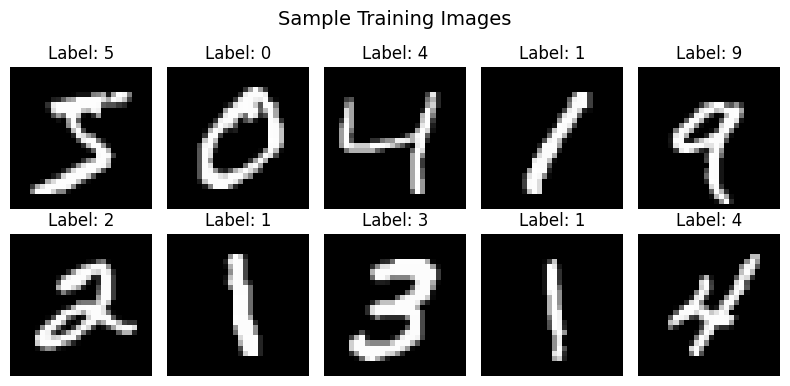

In [ ]:
# 2. TASK 1 – EXPLORATORY DATA ANALYSIS

# Showing the first 10 images with labels
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

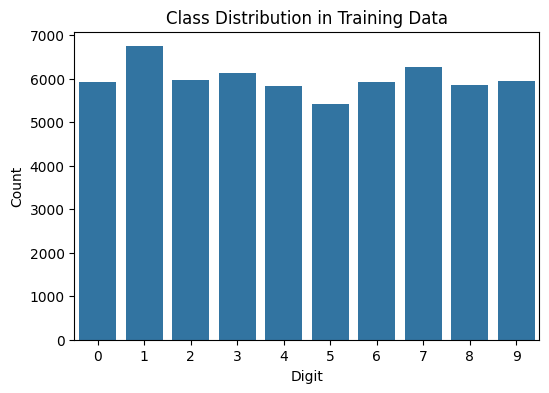

In [ ]:
# Class distribution

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Class Distribution in Training Data")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

In [ ]:
# Pixel intensity statistics and histogram

print("Min pixel value:", x_train.min())
print("Max pixel value:", x_train.max())
print("Mean pixel value:", x_train.mean())
print("Std pixel value:", x_train.std())

Min pixel value: 0
Max pixel value: 255
Mean pixel value: 33.318421449829934
Std pixel value: 78.56748998339798


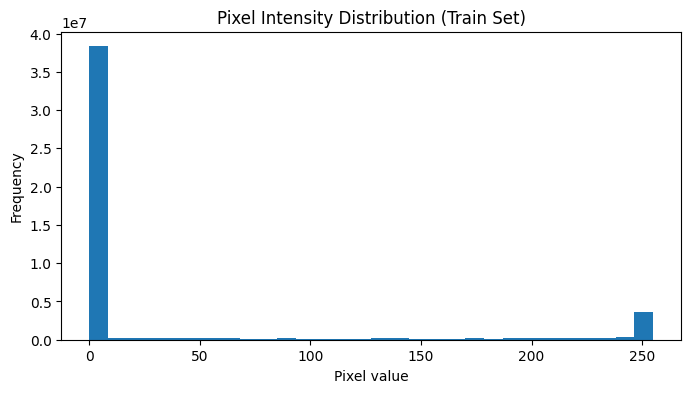

In [ ]:
# Histogram of pixel intensities
plt.figure(figsize=(8, 4))
plt.hist(x_train.reshape(-1), bins=30)
plt.title("Pixel Intensity Distribution (Train Set)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.show()

### EDA Summary (Observations)

- The dataset contains 60,000 training and 10,000 test images, size 28×28 pixels.
- Labels are digits from 0 to 9 and are approximately balanced across the training set.
- Pixel values are grayscale in the range [0, 255].
- Visual inspection shows clear digits but with variations in writing style, thickness, and position.
- Before training, we will **normalize** pixel values to [0, 1] for better model performance.


In [ ]:
# 3. PREPROCESSING

# Normalize pixel values to [0,1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

# Create validation split (20% of training as validation)
X_train, X_val, y_train_split, y_val = train_test_split(
    x_train_norm, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Train (after split):", X_train.shape, y_train_split.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", x_test_norm.shape, y_test.shape)

Train (after split): (48000, 28, 28) (48000,)
Validation: (12000, 28, 28) (12000,)
Test: (10000, 28, 28) (10000,)


In [ ]:
# Flatten images: (28, 28) -> (784,)
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_val_flat   = X_val.reshape((X_val.shape[0], -1))
X_test_flat  = x_test_norm.reshape((x_test_norm.shape[0], -1))

print("Flattened shapes:", X_train_flat.shape, X_val_flat.shape, X_test_flat.shape)

Flattened shapes: (48000, 784) (12000, 784) (10000, 784)


In [ ]:
# One-hot encode labels for neural networks

num_classes = 10

y_train_cat = to_categorical(y_train_split, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print("One-hot label shape (train):", y_train_cat.shape)

One-hot label shape (train): (48000, 10)


In [ ]:
# We’ll store validation accuracy of each model in a dictionary.

In [ ]:
# 4. MODEL TRAINING & COMPARISON

results = {}  # to store validation accuracies


In [ ]:
# 4.1 Logistic Regression

# Using multinomial logistic regression with saga solver for multi-class
log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="saga",
    max_iter=60,       # small but enough; increase if convergence warning
    n_jobs=-1
)

log_reg.fit(X_train_flat, y_train_split)

y_val_pred_log = log_reg.predict(X_val_flat)
log_reg_acc = accuracy_score(y_val, y_val_pred_log)
results["Logistic Regression"] = log_reg_acc

print("Logistic Regression - Validation Accuracy:", log_reg_acc)
print(classification_report(y_val, y_val_pred_log))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression - Validation Accuracy: 0.9213333333333333
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1185
           1       0.95      0.97      0.96      1348
           2       0.91      0.89      0.90      1192
           3       0.90      0.89      0.90      1226
           4       0.93      0.93      0.93      1168
           5       0.87      0.89      0.88      1084
           6       0.95      0.95      0.95      1184
           7       0.95      0.92      0.94      1253
           8       0.89      0.87      0.88      1170
           9       0.89      0.92      0.90      1190

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# 4.2 K-Nearest Neighbors

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_flat, y_train_split)

y_val_pred_knn = knn.predict(X_val_flat)
knn_acc = accuracy_score(y_val, y_val_pred_knn)
results["KNN (k=5)"] = knn_acc

print("KNN (k=5) - Validation Accuracy:", knn_acc)


KNN (k=5) - Validation Accuracy: 0.9675


In [ ]:
# 4.3 SVM (RBF kernel) on subset

subset = 12000  # reduce if your machine is slow

X_train_svm = X_train_flat[:subset]
y_train_svm = y_train_split[:subset]

svm_clf = SVC(kernel="rbf", gamma="scale")

svm_clf.fit(X_train_svm, y_train_svm)

y_val_pred_svm = svm_clf.predict(X_val_flat)
svm_acc = accuracy_score(y_val, y_val_pred_svm)
results["SVM (RBF, subset)"] = svm_acc

print("SVM (RBF, subset) - Validation Accuracy:", svm_acc)


SVM (RBF, subset) - Validation Accuracy: 0.9633333333333334


In [ ]:
# 4.4 Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_flat, y_train_split)
y_val_pred_rf = rf.predict(X_val_flat)
rf_acc = accuracy_score(y_val, y_val_pred_rf)
results["Random Forest"] = rf_acc

print("Random Forest - Validation Accuracy:", rf_acc)


Random Forest - Validation Accuracy: 0.9665


In [ ]:
# 4.5 Dense Neural Network (Fully Connected)

input_dim = X_train_flat.shape[1]

dense_model = Sequential([
    Dense(256, activation="relu", input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(num_classes, activation="softmax")
])

dense_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_dense = dense_model.fit(
    X_train_flat, y_train_cat,
    validation_data=(X_val_flat, y_val_cat),
    epochs=8,          # reduced epochs to make it faster
    batch_size=128,
    verbose=1
)

dense_val_acc = history_dense.history["val_accuracy"][-1]
results["Dense NN"] = dense_val_acc

print("Dense NN - Final Validation Accuracy:", dense_val_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7939 - loss: 0.6809 - val_accuracy: 0.9507 - val_loss: 0.1630
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9483 - loss: 0.1748 - val_accuracy: 0.9629 - val_loss: 0.1217
Epoch 3/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9633 - loss: 0.1192 - val_accuracy: 0.9697 - val_loss: 0.1017
Epoch 4/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9723 - loss: 0.0893 - val_accuracy: 0.9737 - val_loss: 0.0897
Epoch 5/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9755 - loss: 0.0755 - val_accuracy: 0.9758 - val_loss: 0.0838
Epoch 6/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9788 - loss: 0.0656 - val_accuracy: 0.9783 - val_loss: 0.0762
Epoch 7/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9819 - loss: 0.0554 - val_accuracy: 0.9781 - val_loss: 0.0810
Epoch 8/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9846 - loss: 0.0461 - val_accuracy: 0.9781 - v

In [ ]:
# 4.6 Convolutional Neural Network (CNN)

# Add channel dimension for CNN (28,28) -> (28,28,1)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_val_cnn   = X_val.reshape(-1, 28, 28, 1)
X_test_cnn  = x_test_norm.reshape(-1, 28, 28, 1)

cnn_model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=5,         # small but usually enough for good accuracy
    batch_size=128,
    verbose=1
)

cnn_val_acc = history_cnn.history["val_accuracy"][-1]
results["CNN"] = cnn_val_acc

print("CNN - Final Validation Accuracy:", cnn_val_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7883 - loss: 0.6870 - val_accuracy: 0.9740 - val_loss: 0.0819
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9653 - loss: 0.1135 - val_accuracy: 0.9825 - val_loss: 0.0573
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9762 - loss: 0.0825 - val_accuracy: 0.9879 - val_loss: 0.0427
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9819 - loss: 0.0636 - val_accuracy: 0.9892 - val_loss: 0.0389
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9835 - loss: 0.0546 - val_accuracy: 0.9890 - val_loss: 0.0386
CNN - Final Validation Accuracy: 0.9890000224113464


In [ ]:
# Comparison Table & Bar Plot

#  5. MODEL COMPARISON

results_df = pd.DataFrame.from_dict(results, orient="index", columns=["Validation Accuracy"])
results_df = results_df.sort_values("Validation Accuracy", ascending=False)
results_df

,Validation Accuracy
CNN,0.989000
Dense NN,0.978083
KNN (k=5),0.967500
Random Forest,0.966500
"SVM (RBF, subset)",0.963333
Logistic Regression,0.921333


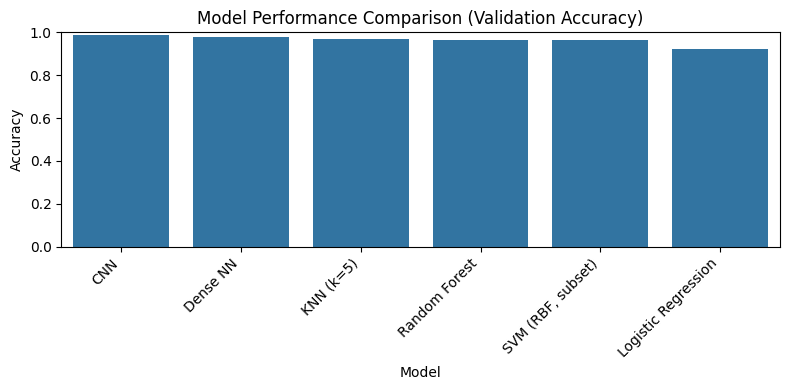

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(x=results_df.index, y="Validation Accuracy", data=results_df)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Model Performance Comparison (Validation Accuracy)")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

### Model Comparison Summary

From the validation accuracy results, we observe:

- **CNN** achieves the highest validation accuracy.
- **Dense Neural Network** performs better than traditional ML models but slightly lower than CNN.
- **Logistic Regression** gives a strong baseline and is fast to train.
- **KNN, SVM, and Random Forest** perform reasonably but are either slower (SVM, KNN) or slightly less accurate than neural networks.

Based on this, **CNN** is selected as the best candidate for production deployment.


In [ ]:
# 6. EVALUATION ON TEST SET (CNN)

test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print("CNN - Test Accuracy:", test_acc)


CNN - Test Accuracy: 0.9904000163078308


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


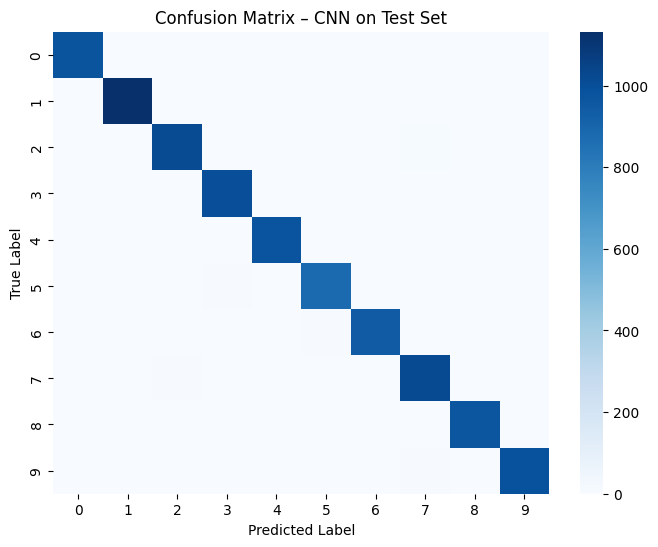

Classification Report (CNN on Test Set):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.98      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
# Predictions on test set
y_test_pred_prob = cnn_model.predict(X_test_cnn)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix – CNN on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Classification Report (CNN on Test Set):")
print(classification_report(y_test, y_test_pred))


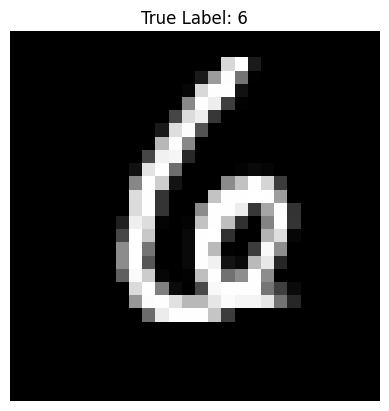

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step
Predicted digit: 6


In [ ]:
# 7. SINGLE IMAGE PREDICTION DEMO (TASK 2)

# Select a random index from test set
idx = 123  # you can change this index

sample_image = x_test_norm[idx]          # shape (28, 28)
sample_label = y_test[idx]

plt.imshow(sample_image, cmap="gray")
plt.title(f"True Label: {sample_label}")
plt.axis("off")
plt.show()

# Prepare image for CNN: add batch and channel dimension -> (1, 28, 28, 1)
sample_input = sample_image.reshape(1, 28, 28, 1)

pred_prob = cnn_model.predict(sample_input)
pred_class = np.argmax(pred_prob, axis=1)[0]

print("Predicted digit:", pred_class)

## Challenges Faced and Techniques Used

### 1. High Dimensional Input and Large Dataset
- Each image has 28×28 = 784 features when flattened.
- Training classical models (SVM, KNN) on the full 60,000 samples is computationally heavy.

**Technique Used:**
- Normalized pixel values to the range [0, 1] to help models converge faster.
- Used a **subset of data** for SVM training to reduce time and memory usage.

---

### 2. Training Time and Resource Limitations
- Deep learning models (Dense NN and CNN) can take a long time to train with many epochs.
- SVM and KNN are slower as the dataset size increases.

**Technique Used:**
- Reduced the number of **epochs** (8 for Dense NN, 5 for CNN) to balance accuracy and speed.
- Used **mini-batch training** (`batch_size=128`) for neural networks.
- Chose a relatively **small CNN architecture** (two convolution + pooling layers).

---

### 3. Overfitting in Neural Networks
- Neural networks can easily overfit if model capacity is high and regularization is low.

**Technique Used:**
- Added **Dropout layers** in both Dense NN and CNN.
- Monitored **validation accuracy** each epoch and used it for model selection.
- Used simple architectures instead of very deep networks.

---

### 4. Hyperparameter Selection
- Many models have hyperparameters that significantly affect accuracy and training time.

**Technique Used:**
- Started with **reasonable default values** (e.g., k=5 in KNN, 100 trees in Random Forest).
- Focused on comparing **model families** rather than exhaustive hyperparameter tuning, due to time and computational constraints.

---

### 5. Choosing a Production-Ready Model

The **CNN** achieved the highest validation and test accuracy and showed good generalization.

**Reasons for selecting CNN for production:**

1. **Highest accuracy** among all models.
2. Learns **spatial features** (strokes, edges, shapes) automatically from image pixels.
3. Can be easily extended to other image classification problems by reusing the architecture.

For environments with limited resources, a **Dense NN or Logistic Regression** can be used as a simpler fallback model with lower accuracy but faster inference.


## Conclusion

- Performed a detailed EDA of the MNIST dataset, including visualization of digits, class distribution, and pixel intensity statistics.
- Built and evaluated several models:
  - Logistic Regression
  - K-Nearest Neighbors
  - SVM with RBF kernel (on a subset)
  - Random Forest
  - Dense Neural Network
  - Convolutional Neural Network (CNN)
- Compared models using validation accuracy and found that **CNN** performs the best.
- Evaluated the CNN on the test set and obtained high test accuracy, confirming good generalization.
- Demonstrated single-image prediction, satisfying the requirement to classify a given handwritten digit.
- Documented key **challenges** (high dimensionality, training time, overfitting, model selection) and the techniques used to address them.

**Recommended production model:**  
A **CNN-based classifier** for best accuracy, with a simpler Dense NN or Logistic Regression as a lightweight backup, depending on deployment constraints.
